<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc" style="margin-top: 1em;"><ul class="toc-item"><li><span><a href="#مقدمة-ل-SURF----الخصائص-القوية-المسرّعة-:" data-toc-modified-id="مقدمة-ل-SURF----الخصائص-القوية-المسرّعة-:-1">مقدمة ل SURF  - الخصائص القوية المسرّعة :</a></span><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#الهدف-:" data-toc-modified-id="الهدف-:-1.0.1">الهدف :</a></span></li><li><span><a href="#النظرية-:" data-toc-modified-id="النظرية-:-1.0.2">النظرية :</a></span></li></ul></li><li><span><a href="#SURF-في-OpenCV:" data-toc-modified-id="SURF-في-OpenCV:-1.1">SURF في OpenCV:</a></span><ul class="toc-item"><li><span><a href="#مراجع-اضافية." data-toc-modified-id="مراجع-اضافية.-1.1.1">مراجع اضافية.</a></span></li><li><span><a href="#تمارين." data-toc-modified-id="تمارين.-1.1.2">تمارين.</a></span></li></ul></li></ul></li></ul></div>

# مقدمة ل SURF  - الخصائص القوية المسرّعة :

### الهدف :

** في هذا الفصل **

* سنرى أسس ال SURF.

* سنرى فعاليات SURF في OpenCV.

### النظرية :



في السابق رأينا اكتشاف الخصائص و الموصفات في SIFT  ولكن بعض الناس تحتاج نسخة أكثر سرعة لهذا , ولذلك في 2006 قام ثلاثة باحثين بوضع خوارزمية أخرى وهي SURF  الخصائص القوية المسرعة.

حيث في SIFT  ثم حساب LoG اما هنا فيتم التبسيط أكثر بحساب المرشح الصندوقي , المتوسط , للصورة , ومن حسناتها الكبيرة أن هذا المرشح يحسب بسهولة بوساطة مكاملة الصورة , ويمكن حسابه بشكل موازي  ولقياسات مختلفة . وأيضاً تعتمد ال SURF  على محدد مصفوفة الHussian  لكل من الموضع والقياس

<img src="../../images/less23-1.png">

ولحساب الاتجاه تعتمد ال SURF  على كل من استجابات Wavlets في كل من الاتجاهين العامودي والافقي , وبجوار بحوالي 6 أضعاف القياس ,  ومن ثم يرسم الناتج كنقاط في الفضاء والكثافة الاعلى يتم أعتمادها كاتجاه مناسب للخاصية , وذلك عن طريق جمع الاستجابات بزاوية متغيرة بقيمة 60 درجة كل مرة .

والامر المثير أن استجابات wavelets  يمكن ايجادها بسهولة بالغة , عند أي قياس .  وللعديد من التطبيقات ثبات الاتجاه غير مطلوب , ولذلك لا داعي لايجاد الزاوية  مما يسرع الخوارزمية  , وتدعى هذه الصيغة U-SURF  , وهي فعالة لحوالي +-15 .  في OpenCV  هناك علم يحدد هل نستخدمها 0 , أم لا 1.

<img src="../../images/less23-2.png">


ولوصف الخصائص نستخدم الاستجابات السابقة بالاتجاهين العامودي و الافقي ,  ولذلك نأخذ جوار 20s X20s  حيث s هي القياس , حول النقطة .  وستقسم ل 4X4 مقطعاً .  ولكل مقطع نأخذ الاستجابات ونشكل الشعاع : $$v = (\sum {d_x},\sum {d_y},\sum {\lvert d_x \rvert},\sum {\lvert d_y \rvert}).$$
 وهذا عند تمثيله كشعاع يعطي موصف ال SURF  ب 64 بعداً وكلما قللناها حصلنا على سرعة أكثر ولكنت على حساب الدقة .
 
 ولدقة أكبر لدى SURF  نمط أخر , نحسب فيه 128 بعداً للموصف , وهذا النمط يمثل في OpenCV بعلم يكون 0 ل 64 بعد أو 1 ل 128 بعد.
 
 وهناك تحسين آخر هو باستخدام إشارة اللابلاسيان , ( أثر مصفوفة هوسيان).
 وهذا لا يزيد التعقيد الحسابي بما أنه محسوب أصلاً أثناء الاكتشاف , وهذه الاشارة توضح الخلفيات العاتمة وراء الاجسام البيضاء  أو الوضع المعاكس  , وعند المطابقة نلاحظ أولاً وضع التباين البيني , وهذه المعلومة البسيطة تسرع الاداء بالمطابقة دون التأثير على أداء الموصف.
 
<img src="../../images/less23-3.png">
 
 باختصار , فانSURF تعطي العديد من الميزات بكل مرحلة , حيث يظهر التحليل أنها أسرع بحوالي 3 مرات من SIFT  بينما الاداء يقارن بال SIFT . 
 
 وال SURF  جيدة للصور المدورة والضبابية , ينما غير جيدة كثيراً للتعامل مع تغير ناحية الرؤية وتغيرات التألق.
 

## SURF في OpenCV:

يعطي OpenCV تابع يقوم باشتقاق الخصائص وفق SURF  مشابه لتابعSIFT  , ونمرر له المداخل المناسبة الاختيارية , ومن ثم نكتشف الخصائص ونحسب الموصفات ..

أولا ً سنأخذ مثالاً بسيطاً :

In [6]:
img = cv2.imread('mario.jpg',0)

انشىء جسم SURF , يمكنك تحديد البارامترات لاحقاً .
ونضع عتبة المصفوفة ل 400.

In [7]:
surf = cv2.SURF(400)

أوجد الخصائص والموصفات مباشرة .

In [9]:
kp, des = surf.detectAndCompute(img,None)
len(kp)

296

296 نقطة عدد ضخم للرسم , لذلك نزيد العتبة لتصل ل 50 نقطة .
وعند المقارنة سنحتاج كل تلك الخصائص ولكن ليس الان 

In [10]:
print surf.hessianThreshold

400.0


سنجعلها مثلاً 5000 . تذكر , هذا فقط للتمثيل بالصورة ..

In [12]:
surf.hessianThreshold = 5000

kp, des = surf.detectAndCompute(img,None)

print len(kp)

61


وهذا مناسب أكثر , لذلك نكتب ,

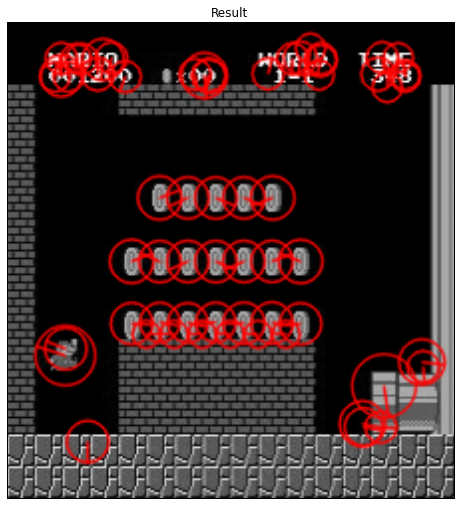

In [14]:
img2 = cv2.drawKeypoints(img,kp,None,(255,0,0),4)

plt.figure(figsize=(8,16))
plt.imshow(img2)
plt.xticks([])
plt.yticks([])
plt.title('Result')
plt.show()

كما يمكن تغيير كل من علم حساب الاتجاه , للتسريع ..

وكذلك علم زيادة طول شعاع الخصائص.


In [15]:
surf.upright = True

# So we make it to True to get 128-dim descriptors.
surf.extended = True

وما تبقى هو المطابقة .. 

### مراجع اضافية.

### تمارين.